# Numerical Model

In [15]:
import numpy as np
import matplotlib.pyplot as plt

class RegressionNumericalView:
    def __init__(self):
        self.B_0 = 0
        self.B_1 = 0
        self.MSE = 0
        self.loss_history = []

    def fit(self, X, y, learning_rate=0.001, epochs=100, l1_lambda=0, l2_lambda=0):
        n = float(len(X))
        self.loss_history = []
        # بنصفر القيم في بداية كل fit
        self.B_0 = 0
        self.B_1 = 0
        
        for i in range(epochs):
            # 1. Prediction
            y_pred = self.B_0 + self.B_1 * X
            
            # 2. Calculate MSE
            current_mse = (1/n) * np.sum((y - y_pred)**2)
            self.loss_history.append(current_mse)
            
            # 3. Derivatives (Gradients)
            D_B0 = (-2/n) * np.sum(y - y_pred)
            
            # إضافة Lasso (L1) و Ridge (L2) في مشتقة الميل (B1)
            lasso_term = l1_lambda * np.sign(self.B_1)
            ridge_term = 2 * l2_lambda * self.B_1
            D_B1 = ((-2/n) * np.sum(X * (y - y_pred))) + lasso_term + ridge_term
            
            # 4. Update Parameters
            self.B_0 = self.B_0 - (learning_rate * D_B0)
            self.B_1 = self.B_1 - (learning_rate * D_B1)
            
        self.MSE = current_mse

    def predict(self, X):
        return self.B_0 + self.B_1 * X

    def plot(self, X, y):
        y_pred = self.predict(X)
        plt.scatter(X, y, color='blue', label='Data points')
        plt.plot(X, y_pred, color='red', label='Regression line')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'SLR: y = {round(self.B_0, 2)} + {round(self.B_1, 2)}x')
        plt.legend()
        plt.show()

    def plot_convergence(self):
        plt.plot(self.loss_history, color='green')
        plt.title('Gradient Descent Convergence')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (MSE)')
        plt.show()

def get_r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

Evaluation Model
B0 (Intercept): -3.459780211866255e-17
B1 (Slope): 0.19142670155292774
Final MSE: 0.9607086671742411


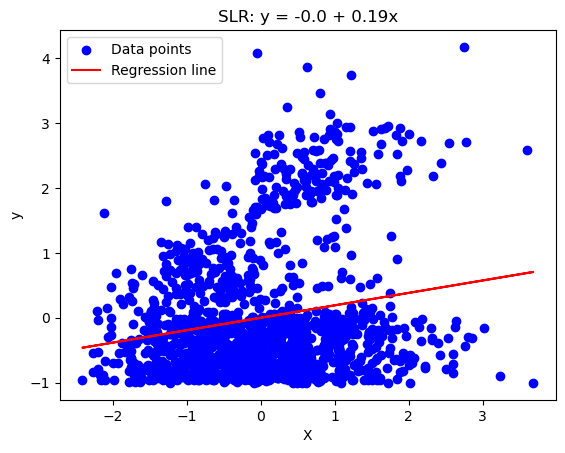

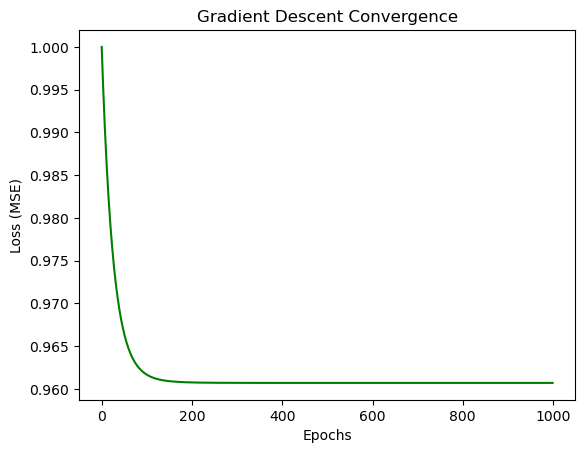

In [14]:
import pandas as pd

df= pd.read_csv(r"C:\Users\Ahmed Sobhy\Downloads\insurance.csv")

X = df['bmi'].values
y = df['charges'].values

X_scaled = (X - X.mean()) / X.std()
y_scaled = (y - y.mean()) / y.std()

model = RegressionNumericalView()

model.fit(X_scaled, y_scaled, learning_rate=0.01, epochs=1000, l1_lambda=0.01, l2_lambda=0.01)

print("Evaluation Model")
print(f"B0 (Intercept): {model.B_0}")
print(f"B1 (Slope): {model.B_1}")
print(f"Final MSE: {model.MSE}")

model.plot(X_scaled, y_scaled)

model.plot_convergence()